# Phase 5 — Transfer Learning with ResNet18

This notebook compares two pretrained ResNet18 configurations:

1. **Frozen ResNet18** — only the new classification head is trained.
2. **Fine-tuned ResNet18** — the complete pretrained network is updated using discriminative learning rates.

Both experiments use:

- the Phase 4 winning augmentation: **Random Crop**
- ImageNet normalization
- weighted cross-entropy
- the existing project `Trainer`
- validation macro F1 as the primary model-comparison metric

The test split is intentionally not loaded or evaluated in this phase.


In [1]:
import copy
import json
import random
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.models import ResNet18_Weights, resnet18


PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.datasets.horse_dataset import HorseGrimaceDataset
from src.training.losses import create_classification_loss
from src.training.trainer import Trainer

print(f"Project root: {PROJECT_ROOT}")
print(f"PyTorch version: {torch.__version__}")


Project root: /home/uteam6/computer-vision-equine-grimace-scale
PyTorch version: 2.5.1+cu121


In [2]:
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")
print(f"Random seed: {SEED}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(
        "Allocated GPU memory:"
        f" {torch.cuda.memory_allocated() / 1024**2:.2f} MB"
    )


Device: cuda
Random seed: 42
GPU: Quadro RTX 4000
Allocated GPU memory: 0.00 MB


In [3]:
TRAIN_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "train.csv"
)

VAL_CSV = (
    PROJECT_ROOT
    / "data"
    / "splits"
    / "validation.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "transfer_learning"
)

CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
HISTORIES_DIR = RESULTS_DIR / "histories"
FIGURES_DIR = RESULTS_DIR / "figures"

for directory in [
    RESULTS_DIR,
    CHECKPOINTS_DIR,
    HISTORIES_DIR,
    FIGURES_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

FROZEN_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR
    / "resnet18_frozen_best.pth"
)

FINETUNED_CHECKPOINT_PATH = (
    CHECKPOINTS_DIR
    / "resnet18_finetuned_best.pth"
)

FROZEN_HISTORY_PATH = (
    HISTORIES_DIR
    / "resnet18_frozen_history.csv"
)

FINETUNED_HISTORY_PATH = (
    HISTORIES_DIR
    / "resnet18_finetuned_history.csv"
)

FROZEN_METRICS_PATH = (
    RESULTS_DIR
    / "resnet18_frozen_validation_metrics.json"
)

FINETUNED_METRICS_PATH = (
    RESULTS_DIR
    / "resnet18_finetuned_validation_metrics.json"
)

EXPERIMENT_SUMMARY_PATH = (
    RESULTS_DIR
    / "experiment_summary.csv"
)

BEST_TRANSFER_MODEL_PATH = (
    RESULTS_DIR
    / "best_transfer_model.pth"
)

BEST_TRANSFER_HISTORY_PATH = (
    RESULTS_DIR
    / "best_transfer_history.csv"
)

BEST_TRANSFER_METADATA_PATH = (
    RESULTS_DIR
    / "best_transfer_model.json"
)

assert TRAIN_CSV.exists(), f"Missing file: {TRAIN_CSV}"
assert VAL_CSV.exists(), f"Missing file: {VAL_CSV}"

print(f"Training CSV:   {TRAIN_CSV}")
print(f"Validation CSV: {VAL_CSV}")
print(f"Results folder: {RESULTS_DIR}")


Training CSV:   /home/uteam6/computer-vision-equine-grimace-scale/data/splits/train.csv
Validation CSV: /home/uteam6/computer-vision-equine-grimace-scale/data/splits/validation.csv
Results folder: /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)

required_columns = {
    "image_path",
    "pain_score",
}

for split_name, dataframe in [
    ("training", train_df),
    ("validation", val_df),
]:
    missing_columns = required_columns.difference(
        dataframe.columns
    )

    assert not missing_columns, (
        f"{split_name.title()} CSV is missing columns: "
        f"{sorted(missing_columns)}"
    )

print(f"Training samples:   {len(train_df):,}")
print(f"Validation samples: {len(val_df):,}")

print("\nTraining class counts:")
display(
    train_df["pain_score"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

print("Validation class counts:")
display(
    val_df["pain_score"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)


Training samples:   2,581
Validation samples: 315

Training class counts:


,count
pain_score,
0,1607
1,555
2,419


Validation class counts:


,count
pain_score,
0,203
1,67
2,45


In [5]:
NUM_CLASSES = 3

train_labels = (
    train_df["pain_score"]
    .astype(int)
    .to_numpy()
)

class_indices = np.arange(NUM_CLASSES)

missing_classes = set(class_indices).difference(
    np.unique(train_labels)
)

assert not missing_classes, (
    "The training split is missing classes: "
    f"{sorted(missing_classes)}"
)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=train_labels,
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
)

print("Class weights:")

for class_index, class_weight in zip(
    class_indices,
    class_weights_array,
):
    print(
        f"Pain Score {class_index}: "
        f"{class_weight:.4f}"
    )


Class weights:
Pain Score 0: 0.5354
Pain Score 1: 1.5502
Pain Score 2: 2.0533


In [6]:
IMAGE_SIZE = 224
RESIZE_SIZE = 256

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225,
]

train_transform = transforms.Compose(
    [
        transforms.Resize(
            (RESIZE_SIZE, RESIZE_SIZE)
        ),
        transforms.RandomCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

validation_transform = transforms.Compose(
    [
        transforms.Resize(
            (RESIZE_SIZE, RESIZE_SIZE)
        ),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STD,
        ),
    ]
)

print("Training transform:")
print(train_transform)

print("\nValidation transform:")
print(validation_transform)


Training transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation transform:
Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [7]:
IMAGE_ROOT = PROJECT_ROOT

train_dataset = HorseGrimaceDataset(
    csv_file=TRAIN_CSV,
    image_root=IMAGE_ROOT,
    transform=train_transform,
    verify_images=True,
)

val_dataset = HorseGrimaceDataset(
    csv_file=VAL_CSV,
    image_root=IMAGE_ROOT,
    transform=validation_transform,
    verify_images=True,
)

BATCH_SIZE = 32
NUM_WORKERS = 4

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
    generator=loader_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=NUM_WORKERS > 0,
)

print(f"Training batches:   {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")


Training batches:   81
Validation batches: 10


In [8]:
batch = next(iter(train_loader))

images = batch["image"]
targets = batch["pain_score"]

print(f"Batch keys: {list(batch.keys())}")
print(f"Image shape: {images.shape}")
print(f"Target shape: {targets.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Target dtype: {targets.dtype}")
print(f"Unique labels: {targets.unique(sorted=True)}")
print(f"Minimum normalized value: {images.min().item():.4f}")
print(f"Maximum normalized value: {images.max().item():.4f}")

assert images.ndim == 4
assert images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
)
assert targets.dtype == torch.long


Batch keys: ['image', 'pain_score', 'horse_id', 'face_region', 'image_path']
Image shape: torch.Size([32, 3, 224, 224])
Target shape: torch.Size([32])
Image dtype: torch.float32
Target dtype: torch.int64
Unique labels: tensor([0, 1, 2])
Minimum normalized value: -2.1179
Maximum normalized value: 2.6400


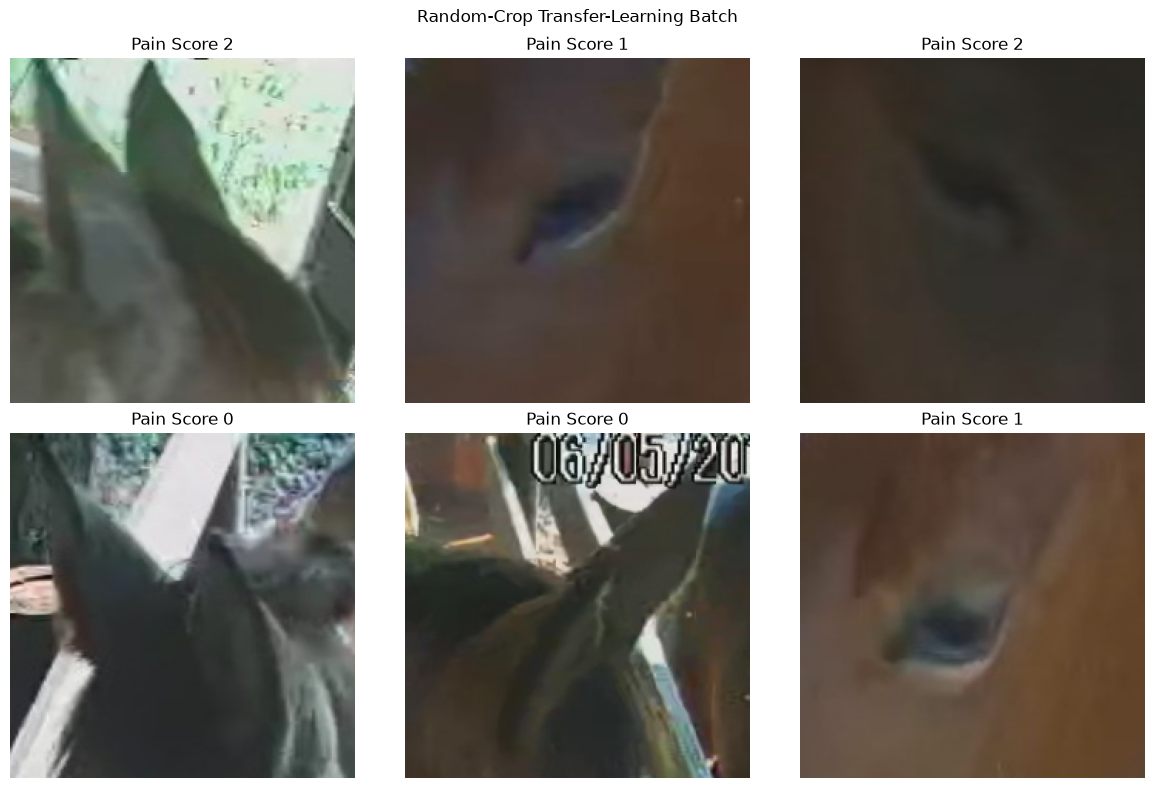

In [9]:
def denormalize_image(
    image_tensor: torch.Tensor,
) -> np.ndarray:
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    std = torch.tensor(
        IMAGENET_STD,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    image = (
        image_tensor.detach().cpu() * std + mean
    )

    image = image.clamp(0.0, 1.0)

    return image.permute(1, 2, 0).numpy()


num_examples = min(6, len(images))

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
)

axes = np.asarray(axes).reshape(-1)

for axis, image, target in zip(
    axes,
    images[:num_examples],
    targets[:num_examples],
):
    axis.imshow(
        denormalize_image(image)
    )
    axis.set_title(
        f"Pain Score {int(target)}"
    )
    axis.axis("off")

for axis in axes[num_examples:]:
    axis.axis("off")

plt.suptitle(
    "Random-Crop Transfer-Learning Batch"
)
plt.tight_layout()
plt.show()


In [10]:
class TransferResNet18(nn.Module):
    def __init__(
        self,
        num_classes: int = 3,
        dropout_rate: float = 0.5,
        freeze_backbone: bool = False,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        self.freeze_backbone = freeze_backbone
        self.pretrained_weights_name = (
            "ResNet18_Weights.DEFAULT"
        )

        self.network = resnet18(
            weights=ResNet18_Weights.DEFAULT
        )

        in_features = self.network.fc.in_features

        self.network.fc = nn.Sequential(
            nn.Dropout(
                p=dropout_rate
            ),
            nn.Linear(
                in_features,
                num_classes,
            ),
        )

        if freeze_backbone:
            self.freeze_feature_extractor()

    def freeze_feature_extractor(self) -> None:
        for parameter_name, parameter in (
            self.network.named_parameters()
        ):
            parameter.requires_grad = (
                parameter_name.startswith("fc.")
            )

    def train(
        self,
        mode: bool = True,
    ):
        super().train(mode)

        if mode and self.freeze_backbone:
            for module_name, module in (
                self.network.named_children()
            ):
                if module_name != "fc":
                    module.eval()

            self.network.fc.train(True)

        return self

    def forward(
        self,
        images: torch.Tensor,
    ) -> torch.Tensor:
        return self.network(images)


def build_resnet18(
    training_mode: str,
    num_classes: int = NUM_CLASSES,
    dropout_rate: float = 0.5,
) -> TransferResNet18:
    valid_modes = {
        "frozen",
        "fine_tuned",
    }

    if training_mode not in valid_modes:
        raise ValueError(
            f"training_mode must be one of "
            f"{sorted(valid_modes)}."
        )

    return TransferResNet18(
        num_classes=num_classes,
        dropout_rate=dropout_rate,
        freeze_backbone=(
            training_mode == "frozen"
        ),
    )


def count_parameters(
    model: nn.Module,
) -> dict[str, int]:
    total = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    return {
        "total": total,
        "trainable": trainable,
        "frozen": total - trainable,
    }


In [11]:
frozen_test_model = build_resnet18(
    training_mode="frozen",
).to(device)

finetuned_test_model = build_resnet18(
    training_mode="fine_tuned",
).to(device)

dummy_images = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=device,
)

with torch.no_grad():
    frozen_outputs = frozen_test_model(
        dummy_images
    )
    finetuned_outputs = finetuned_test_model(
        dummy_images
    )

print(
    "Frozen output shape:",
    frozen_outputs.shape,
)

print(
    "Fine-tuned output shape:",
    finetuned_outputs.shape,
)

print(
    "\nFrozen parameter counts:",
    count_parameters(frozen_test_model),
)

print(
    "Fine-tuned parameter counts:",
    count_parameters(finetuned_test_model),
)

assert frozen_outputs.shape == (
    2,
    NUM_CLASSES,
)

assert finetuned_outputs.shape == (
    2,
    NUM_CLASSES,
)

del frozen_test_model
del finetuned_test_model
del dummy_images
del frozen_outputs
del finetuned_outputs

if torch.cuda.is_available():
    torch.cuda.empty_cache()


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/uteam6/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s] 


Frozen output shape: torch.Size([2, 3])
Fine-tuned output shape: torch.Size([2, 3])

Frozen parameter counts: {'total': 11178051, 'trainable': 1539, 'frozen': 11176512}
Fine-tuned parameter counts: {'total': 11178051, 'trainable': 11178051, 'frozen': 0}


In [12]:
DROPOUT_RATE = 0.5
NUM_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 10
WEIGHT_DECAY = 1e-4


def make_serializable(value):
    if isinstance(value, torch.Tensor):
        if value.numel() == 1:
            return value.item()

        return value.detach().cpu().tolist()

    if isinstance(value, np.ndarray):
        return value.tolist()

    if isinstance(value, np.generic):
        return value.item()

    if isinstance(value, Path):
        return str(value)

    if isinstance(value, dict):
        return {
            str(key): make_serializable(item)
            for key, item in value.items()
        }

    if isinstance(value, (list, tuple)):
        return [
            make_serializable(item)
            for item in value
        ]

    return value


def get_history_value(
    history_row: pd.Series,
    possible_column_names: list[str],
    required: bool = True,
):
    for column_name in possible_column_names:
        if column_name in history_row.index:
            return float(
                history_row[column_name]
            )

    if required:
        raise KeyError(
            "None of the expected history columns "
            "were found. "
            f"Expected one of: {possible_column_names}. "
            f"Available columns: "
            f"{history_row.index.tolist()}"
        )

    return None


def build_optimizer(
    model: TransferResNet18,
    training_mode: str,
):
    if training_mode == "frozen":
        optimizer = torch.optim.Adam(
            filter(
                lambda parameter: (
                    parameter.requires_grad
                ),
                model.parameters(),
            ),
            lr=1e-3,
            weight_decay=WEIGHT_DECAY,
        )

        learning_rate_description = {
            "classifier": 1e-3,
        }

    elif training_mode == "fine_tuned":
        backbone_parameters = []
        classifier_parameters = []

        for parameter_name, parameter in (
            model.network.named_parameters()
        ):
            if parameter_name.startswith("fc."):
                classifier_parameters.append(
                    parameter
                )
            else:
                backbone_parameters.append(
                    parameter
                )

        optimizer = torch.optim.Adam(
            [
                {
                    "params": backbone_parameters,
                    "lr": 1e-5,
                },
                {
                    "params": classifier_parameters,
                    "lr": 1e-4,
                },
            ],
            weight_decay=WEIGHT_DECAY,
        )

        learning_rate_description = {
            "backbone": 1e-5,
            "classifier": 1e-4,
        }

    else:
        raise ValueError(
            "Unsupported training mode: "
            f"{training_mode}"
        )

    return optimizer, learning_rate_description


def save_history_curves(
    history_df: pd.DataFrame,
    experiment_name: str,
    display_name: str,
) -> Path:
    epochs = np.arange(
        1,
        len(history_df) + 1,
    )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(14, 10),
    )

    axes = axes.flatten()

    axes[0].plot(
        epochs,
        history_df["train_loss"],
        label="Training Loss",
    )
    axes[0].plot(
        epochs,
        history_df["val_loss"],
        label="Validation Loss",
    )
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(
        epochs,
        history_df["train_accuracy"],
        label="Training Accuracy",
    )
    axes[1].plot(
        epochs,
        history_df["val_accuracy"],
        label="Validation Accuracy",
    )
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(
        epochs,
        history_df["val_macro_f1"],
        label="Validation Macro F1",
    )
    axes[2].set_title(
        "Validation Macro F1"
    )
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Macro F1")
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    axes[3].plot(
        epochs,
        history_df["learning_rate"],
        label="Recorded Learning Rate",
    )
    axes[3].set_title("Learning Rate")
    axes[3].set_xlabel("Epoch")
    axes[3].set_ylabel("Learning Rate")
    axes[3].legend()
    axes[3].grid(alpha=0.3)

    fig.suptitle(
        f"{display_name} Training Curves"
    )
    fig.tight_layout()

    figure_path = (
        FIGURES_DIR
        / f"{experiment_name}_curves.png"
    )

    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    return figure_path


def evaluate_trained_model(
    trainer: Trainer,
    checkpoint_path: Path,
    history_path: Path,
    training_mode: str,
    learning_rates: dict,
    metrics_path: Path,
) -> tuple[dict, pd.DataFrame]:
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    trainer.model.load_state_dict(
        checkpoint["model_state_dict"]
    )

    trainer.model.eval()

    validation_results = trainer.predict(
        val_loader
    )

    validation_metrics = (
        validation_results["metrics"]
    )

    history_df = pd.read_csv(
        history_path
    )

    checkpoint_epoch = int(
        checkpoint["epoch"]
    )

    history_index = checkpoint_epoch - 1

    if not (
        0 <= history_index < len(history_df)
    ):
        raise IndexError(
            "Checkpoint epoch does not match "
            "the saved history. "
            f"Checkpoint epoch: {checkpoint_epoch}; "
            f"history rows: {len(history_df)}."
        )

    checkpoint_history_row = history_df.iloc[
        history_index
    ]

    train_accuracy = get_history_value(
        checkpoint_history_row,
        ["train_accuracy"],
    )

    val_accuracy = float(
        validation_metrics["accuracy"]
    )

    accuracy_gap = (
        train_accuracy - val_accuracy
    )

    metrics_record = {
        "architecture": "resnet18",
        "training_mode": training_mode,
        "num_classes": NUM_CLASSES,
        "dropout_rate": DROPOUT_RATE,
        "pretrained_weights": (
            "ResNet18_Weights.DEFAULT"
        ),
        "augmentation": "random_crop",
        "normalization": "imagenet",
        "checkpoint_selection_metric": (
            "validation_loss"
        ),
        "best_checkpoint_epoch": (
            checkpoint_epoch
        ),
        "best_checkpoint_validation_loss": (
            float(
                checkpoint[
                    "validation_loss"
                ]
            )
        ),
        "validation_loss": (
            get_history_value(
                checkpoint_history_row,
                ["val_loss"],
            )
        ),
        "validation_accuracy": (
            val_accuracy
        ),
        "validation_macro_precision": (
            float(
                validation_metrics[
                    "macro_precision"
                ]
            )
        ),
        "validation_macro_recall": (
            float(
                validation_metrics[
                    "macro_recall"
                ]
            )
        ),
        "validation_macro_f1": (
            float(
                validation_metrics[
                    "macro_f1"
                ]
            )
        ),
        "validation_weighted_f1": (
            float(
                validation_metrics[
                    "weighted_f1"
                ]
            )
        ),
        "training_accuracy_at_checkpoint": (
            train_accuracy
        ),
        "accuracy_overfitting_gap": (
            accuracy_gap
        ),
        "learning_rates": learning_rates,
        "checkpoint_path": str(
            checkpoint_path
        ),
        "history_path": str(
            history_path
        ),
    }

    with open(
        metrics_path,
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            make_serializable(
                metrics_record
            ),
            output_file,
            indent=4,
        )

    return metrics_record, history_df


def run_experiment(
    training_mode: str,
    display_name: str,
    checkpoint_path: Path,
    history_path: Path,
    metrics_path: Path,
):
    set_seed()

    model = build_resnet18(
        training_mode=training_mode,
        num_classes=NUM_CLASSES,
        dropout_rate=DROPOUT_RATE,
    ).to(device)

    parameter_counts = count_parameters(
        model
    )

    print(
        f"\n{display_name}"
    )
    print(
        f"Total parameters: "
        f"{parameter_counts['total']:,}"
    )
    print(
        f"Trainable parameters: "
        f"{parameter_counts['trainable']:,}"
    )
    print(
        f"Frozen parameters: "
        f"{parameter_counts['frozen']:,}"
    )

    criterion = create_classification_loss(
        class_weights=class_weights,
        device=device,
    )

    optimizer, learning_rates = (
        build_optimizer(
            model=model,
            training_mode=training_mode,
        )
    )

    scheduler = (
        torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
        )
    )

    trainer = Trainer(
        model=model,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_classes=NUM_CLASSES,
        scheduler=scheduler,
        checkpoint_path=checkpoint_path,
        early_stopping_patience=(
            EARLY_STOPPING_PATIENCE
        ),
        early_stopping_min_delta=0.0,
    )

    history = trainer.fit(
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=NUM_EPOCHS,
    )

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        history_path,
        index=False,
    )

    save_history_curves(
        history_df=history_df,
        experiment_name=(
            f"resnet18_{training_mode}"
        ),
        display_name=display_name,
    )

    metrics_record, history_df = (
        evaluate_trained_model(
            trainer=trainer,
            checkpoint_path=checkpoint_path,
            history_path=history_path,
            training_mode=training_mode,
            learning_rates=learning_rates,
            metrics_path=metrics_path,
        )
    )

    metrics_record.update(
        {
            "total_parameters": (
                parameter_counts["total"]
            ),
            "trainable_parameters": (
                parameter_counts["trainable"]
            ),
            "frozen_parameters": (
                parameter_counts["frozen"]
            ),
        }
    )

    with open(
        metrics_path,
        "w",
        encoding="utf-8",
    ) as output_file:
        json.dump(
            make_serializable(
                metrics_record
            ),
            output_file,
            indent=4,
        )

    return {
        "model": model,
        "trainer": trainer,
        "history_df": history_df,
        "metrics": metrics_record,
    }



Frozen ResNet18
Total parameters: 11,178,051
Trainable parameters: 1,539
Frozen parameters: 11,176,512


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.0871 | Train Acc: 0.5079 | Val Loss: 0.7830 | Val Acc: 0.7048 | Macro F1: 0.5782 | LR: 1.00e-03
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 016/050 | Train Loss: 0.8349 | Train Acc: 0.6544 | Val Loss: 0.6737 | Val Acc: 0.7492 | Macro F1: 0.6433 | LR: 2.50e-04


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 017/050 | Train Loss: 0.8454 | Train Acc: 0.6370 | Val Loss: 0.6769 | Val Acc: 0.7365 | Macro F1: 0.6215 | LR: 2.50e-04
Early stopping triggered at epoch 17.


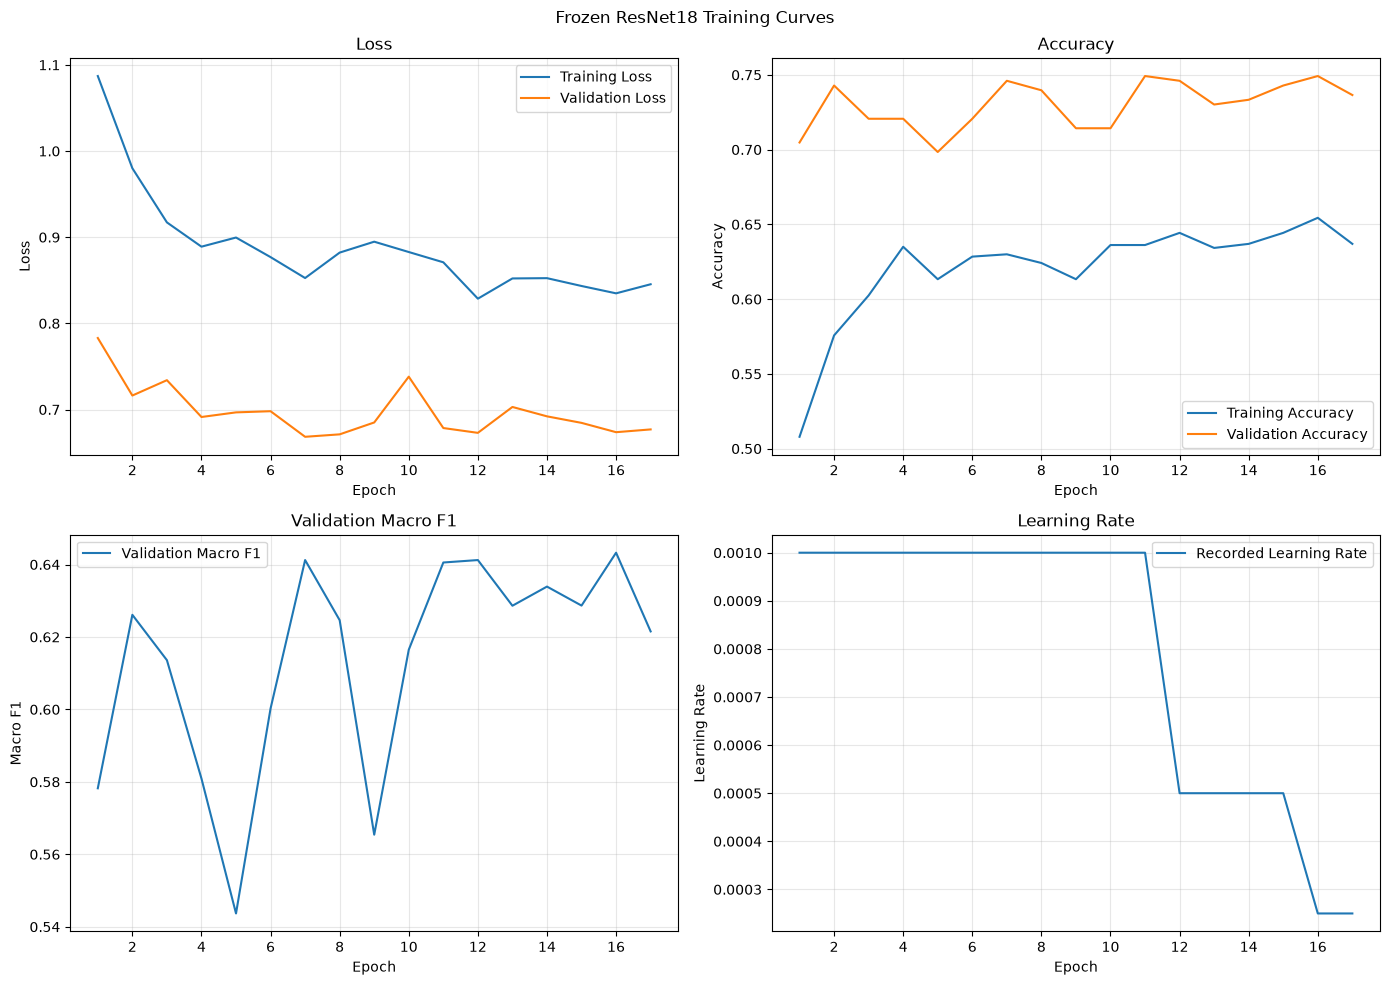

Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,learning_rate
12,0.852161,0.634250,0.703002,0.730159,0.626297,0.654856,0.628620,0.742900,0.00050
13,0.852487,0.636962,0.692117,0.733333,0.627954,0.659831,0.633905,0.745392,0.00050
14,0.843399,0.644324,0.684537,0.742857,0.670846,0.663586,0.628661,0.749235,0.00050
15,0.834869,0.654398,0.673724,0.749206,0.649047,0.664708,0.643257,0.759704,0.00025
16,0.845407,0.636962,0.676944,0.736508,0.640582,0.649672,0.621531,0.744810,0.00025



Frozen validation metrics:
best_checkpoint_epoch: 7
validation_loss: 0.6683848842741951
validation_accuracy: 0.746031746031746
validation_macro_precision: 0.6381937129458106
validation_macro_recall: 0.6630661688819176
validation_macro_f1: 0.6412276851883935
validation_weighted_f1: 0.7547130114071662
accuracy_overfitting_gap: -0.11604336943352833


In [13]:
frozen_experiment = run_experiment(
    training_mode="frozen",
    display_name="Frozen ResNet18",
    checkpoint_path=FROZEN_CHECKPOINT_PATH,
    history_path=FROZEN_HISTORY_PATH,
    metrics_path=FROZEN_METRICS_PATH,
)

display(
    frozen_experiment[
        "history_df"
    ].tail()
)

print("\nFrozen validation metrics:")

for metric_name, metric_value in (
    frozen_experiment["metrics"].items()
):
    if metric_name.startswith(
        "validation_"
    ) or metric_name in {
        "best_checkpoint_epoch",
        "accuracy_overfitting_gap",
    }:
        print(
            f"{metric_name}: {metric_value}"
        )


In [14]:
del frozen_experiment

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("Frozen experiment memory released.")


Frozen experiment memory released.



Fine-Tuned ResNet18
Total parameters: 11,178,051
Trainable parameters: 11,178,051
Frozen parameters: 0


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001/050 | Train Loss: 1.1186 | Train Acc: 0.4618 | Val Loss: 0.7473 | Val Acc: 0.7270 | Macro F1: 0.6063 | LR: 1.00e-05
Saved new best checkpoint.


Training:   0%|          | 0/81 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 017/050 | Train Loss: 0.2767 | Train Acc: 0.9020 | Val Loss: 0.6509 | Val Acc: 0.7714 | Macro F1: 0.6830 | LR: 2.50e-06


Training:   0%|          | 0/81 [00:00<?, ?it/s]

Validation:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 018/050 | Train Loss: 0.2609 | Train Acc: 0.9124 | Val Loss: 0.6935 | Val Acc: 0.7683 | Macro F1: 0.6717 | LR: 2.50e-06
Early stopping triggered at epoch 18.


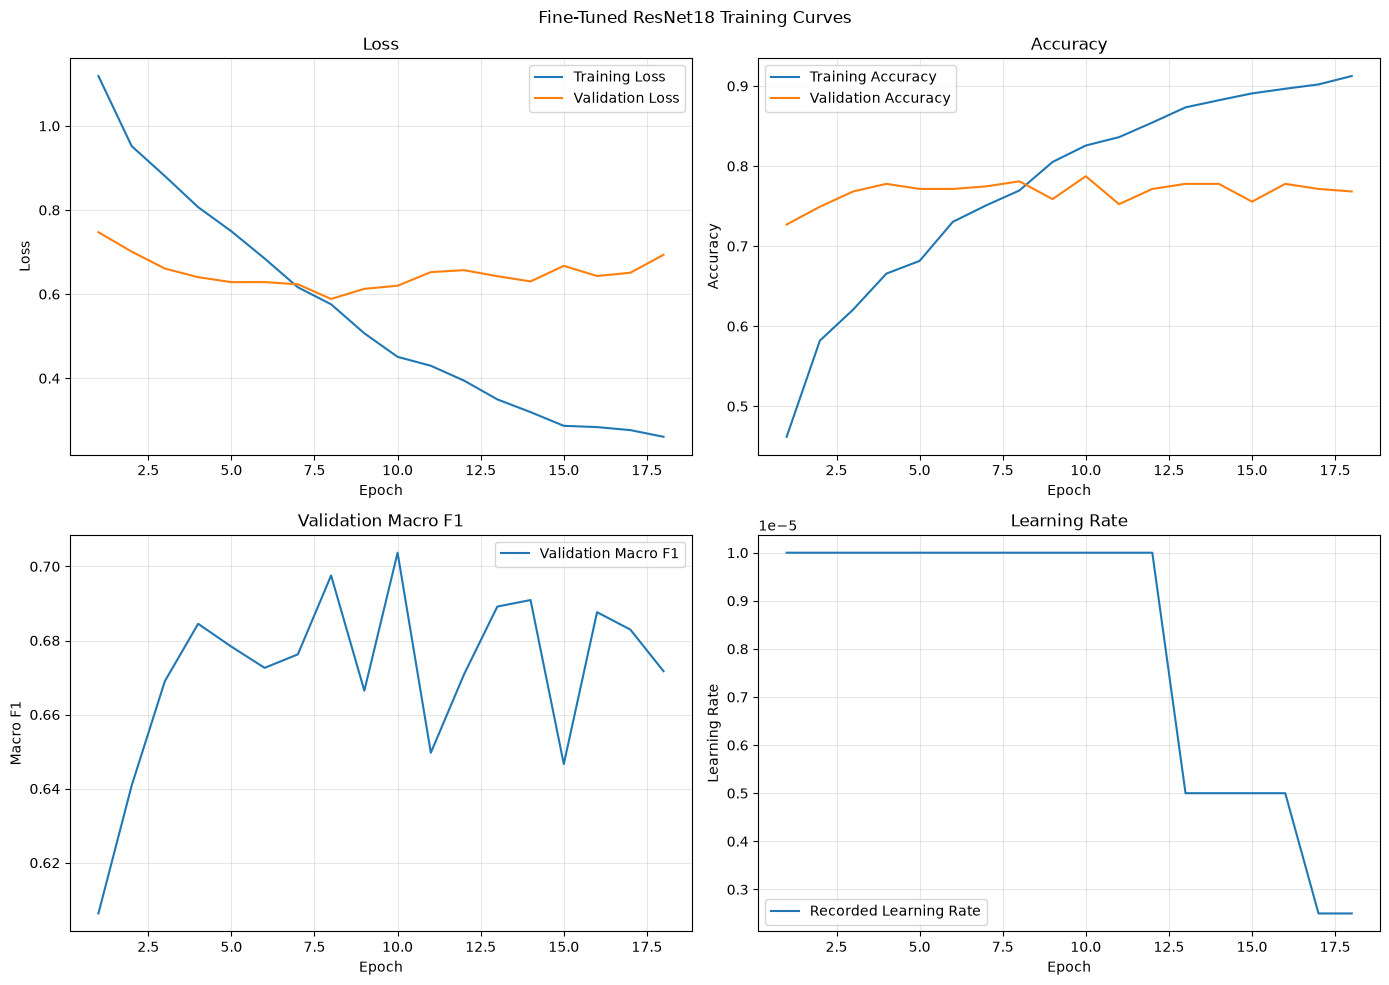

Evaluation:   0%|          | 0/10 [00:00<?, ?it/s]

,train_loss,train_accuracy,val_loss,val_accuracy,val_macro_precision,val_macro_recall,val_macro_f1,val_weighted_f1,learning_rate
13,0.319540,0.882216,0.630254,0.777778,0.687470,0.694620,0.690925,0.779133,0.000005
14,0.286911,0.890740,0.667267,0.755556,0.646596,0.653128,0.646644,0.754673,0.000005
15,0.283902,0.896552,0.643143,0.777778,0.684234,0.691287,0.687641,0.779180,0.000005
16,0.276743,0.901976,0.650857,0.771429,0.674170,0.693769,0.682962,0.775687,0.000003
17,0.260856,0.912437,0.693504,0.768254,0.673034,0.673029,0.671718,0.766831,0.000003



Fine-tuned validation metrics:
best_checkpoint_epoch: 8
validation_loss: 0.5885753699711391
validation_accuracy: 0.780952380952381
validation_macro_precision: 0.6884557259329848
validation_macro_recall: 0.7086940775051943
validation_macro_f1: 0.6975608834302688
validation_weighted_f1: 0.7850020589480774
accuracy_overfitting_gap: -0.011483182967103933


In [15]:
finetuned_experiment = run_experiment(
    training_mode="fine_tuned",
    display_name="Fine-Tuned ResNet18",
    checkpoint_path=FINETUNED_CHECKPOINT_PATH,
    history_path=FINETUNED_HISTORY_PATH,
    metrics_path=FINETUNED_METRICS_PATH,
)

display(
    finetuned_experiment[
        "history_df"
    ].tail()
)

print("\nFine-tuned validation metrics:")

for metric_name, metric_value in (
    finetuned_experiment["metrics"].items()
):
    if metric_name.startswith(
        "validation_"
    ) or metric_name in {
        "best_checkpoint_epoch",
        "accuracy_overfitting_gap",
    }:
        print(
            f"{metric_name}: {metric_value}"
        )


In [16]:
with open(
    FROZEN_METRICS_PATH,
    "r",
    encoding="utf-8",
) as input_file:
    frozen_metrics = json.load(
        input_file
    )

with open(
    FINETUNED_METRICS_PATH,
    "r",
    encoding="utf-8",
) as input_file:
    finetuned_metrics = json.load(
        input_file
    )

frozen_history_df = pd.read_csv(
    FROZEN_HISTORY_PATH
)

finetuned_history_df = pd.read_csv(
    FINETUNED_HISTORY_PATH
)

print("Saved experiment records loaded.")


Saved experiment records loaded.


In [17]:
summary_columns = [
    "training_mode",
    "validation_loss",
    "validation_accuracy",
    "validation_macro_precision",
    "validation_macro_recall",
    "validation_macro_f1",
    "validation_weighted_f1",
    "training_accuracy_at_checkpoint",
    "accuracy_overfitting_gap",
    "best_checkpoint_epoch",
    "total_parameters",
    "trainable_parameters",
]

experiment_summary_df = pd.DataFrame(
    [
        frozen_metrics,
        finetuned_metrics,
    ]
)[summary_columns]

experiment_summary_df = (
    experiment_summary_df.sort_values(
        by="validation_macro_f1",
        ascending=False,
    )
    .reset_index(drop=True)
)

experiment_summary_df.to_csv(
    EXPERIMENT_SUMMARY_PATH,
    index=False,
)

display(experiment_summary_df)

print(
    "Experiment summary saved to:"
    f" {EXPERIMENT_SUMMARY_PATH}"
)


,training_mode,validation_loss,validation_accuracy,validation_macro_precision,validation_macro_recall,validation_macro_f1,validation_weighted_f1,training_accuracy_at_checkpoint,accuracy_overfitting_gap,best_checkpoint_epoch,total_parameters,trainable_parameters
0,fine_tuned,0.588575,0.780952,0.688456,0.708694,0.697561,0.785002,0.769469,-0.011483,8,11178051,11178051
1,frozen,0.668385,0.746032,0.638194,0.663066,0.641228,0.754713,0.629988,-0.116043,7,11178051,1539


Experiment summary saved to: /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/experiment_summary.csv


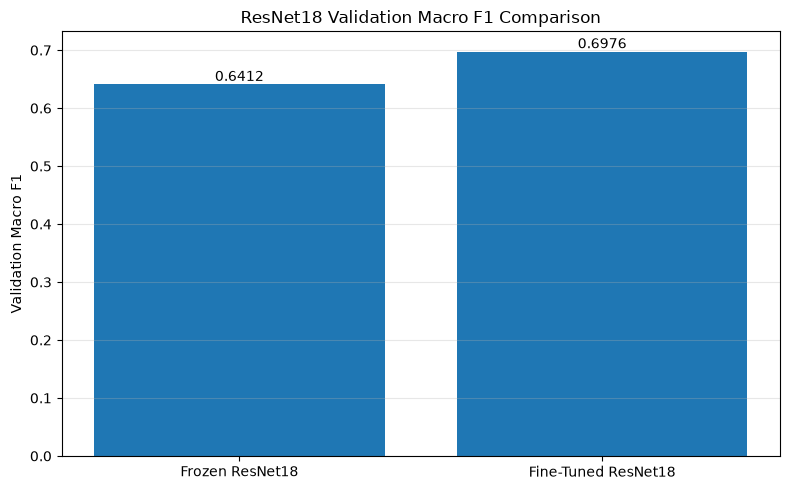

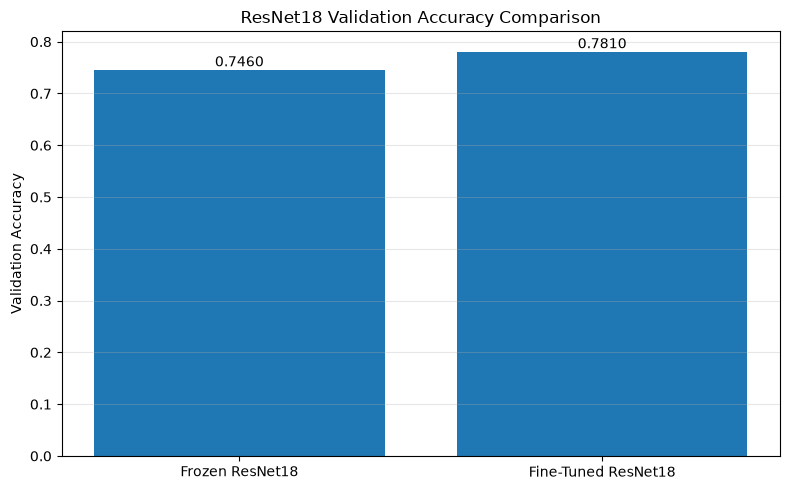

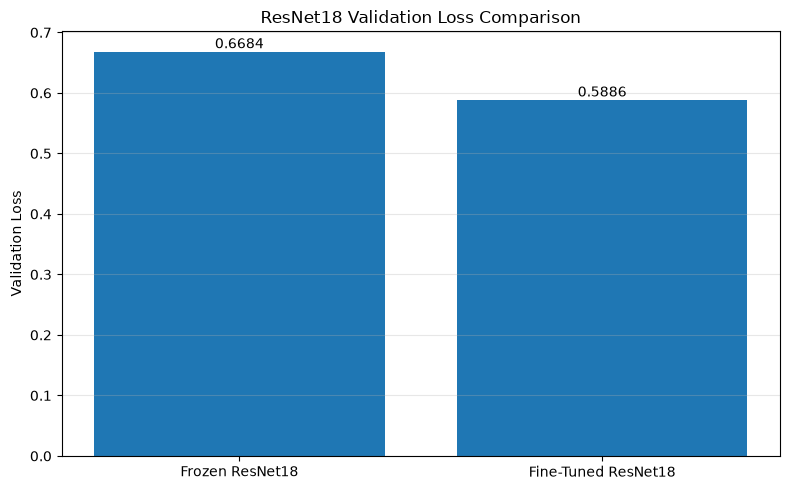

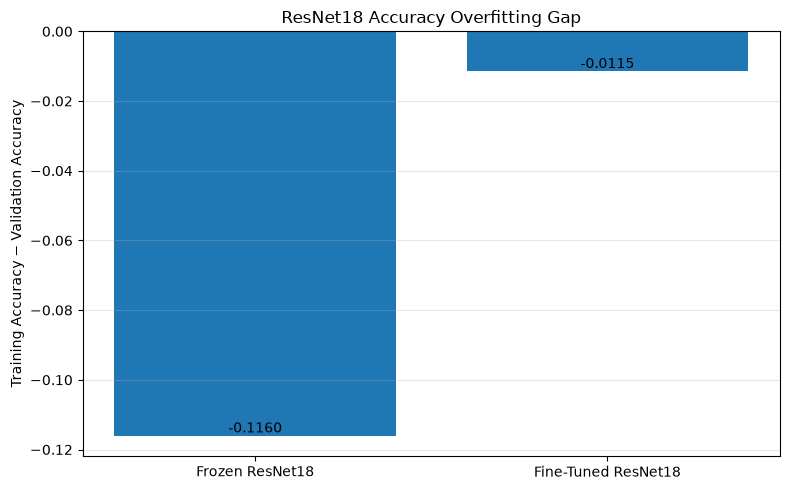

In [18]:
comparison_labels = [
    "Frozen ResNet18",
    "Fine-Tuned ResNet18",
]

comparison_records = [
    frozen_metrics,
    finetuned_metrics,
]


def save_bar_comparison(
    metric_key: str,
    ylabel: str,
    title: str,
    filename: str,
) -> None:
    values = [
        float(record[metric_key])
        for record in comparison_records
    ]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(
        comparison_labels,
        values,
    )

    for bar, value in zip(
        bars,
        values,
    ):
        plt.text(
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.4f}",
            ha="center",
            va="bottom",
        )

    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(
        axis="y",
        alpha=0.3,
    )
    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


save_bar_comparison(
    metric_key="validation_macro_f1",
    ylabel="Validation Macro F1",
    title=(
        "ResNet18 Validation Macro F1 "
        "Comparison"
    ),
    filename=(
        "validation_macro_f1_comparison.png"
    ),
)

save_bar_comparison(
    metric_key="validation_accuracy",
    ylabel="Validation Accuracy",
    title=(
        "ResNet18 Validation Accuracy "
        "Comparison"
    ),
    filename=(
        "validation_accuracy_comparison.png"
    ),
)

save_bar_comparison(
    metric_key="validation_loss",
    ylabel="Validation Loss",
    title=(
        "ResNet18 Validation Loss "
        "Comparison"
    ),
    filename=(
        "validation_loss_comparison.png"
    ),
)

save_bar_comparison(
    metric_key="accuracy_overfitting_gap",
    ylabel=(
        "Training Accuracy − "
        "Validation Accuracy"
    ),
    title=(
        "ResNet18 Accuracy "
        "Overfitting Gap"
    ),
    filename=(
        "accuracy_overfitting_gap.png"
    ),
)


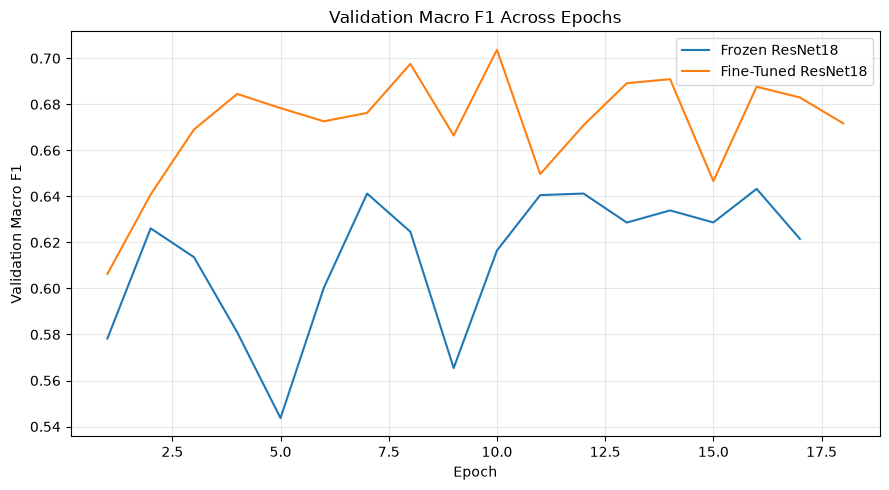

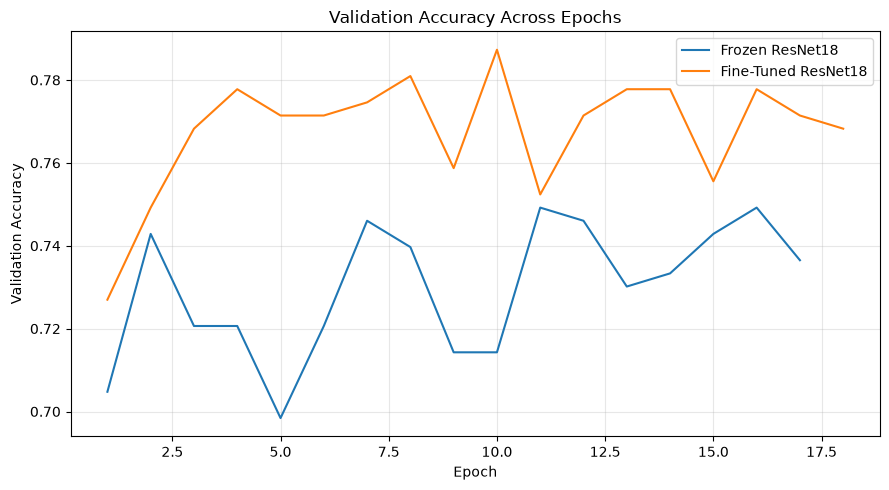

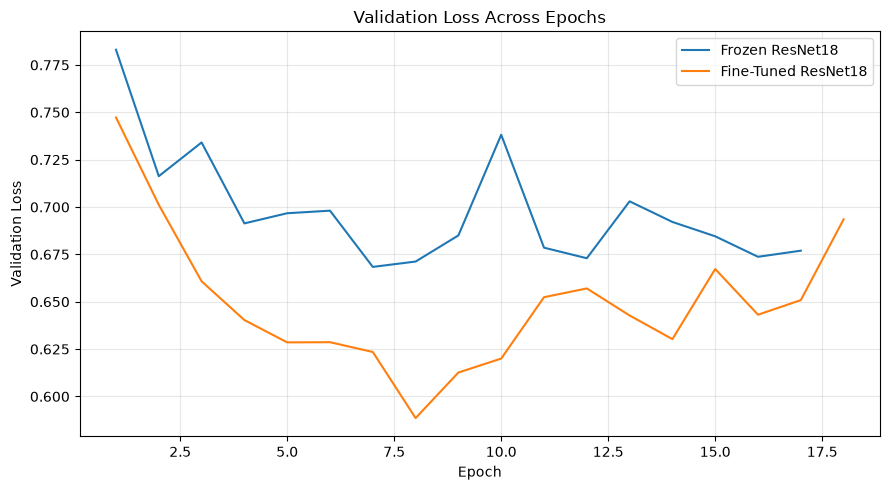

In [19]:
def plot_history_comparison(
    metric_column: str,
    ylabel: str,
    title: str,
    filename: str,
) -> None:
    plt.figure(figsize=(9, 5))

    plt.plot(
        np.arange(
            1,
            len(frozen_history_df) + 1,
        ),
        frozen_history_df[
            metric_column
        ],
        label="Frozen ResNet18",
    )

    plt.plot(
        np.arange(
            1,
            len(finetuned_history_df) + 1,
        ),
        finetuned_history_df[
            metric_column
        ],
        label="Fine-Tuned ResNet18",
    )

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    output_path = (
        FIGURES_DIR
        / filename
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()


plot_history_comparison(
    metric_column="val_macro_f1",
    ylabel="Validation Macro F1",
    title=(
        "Validation Macro F1 "
        "Across Epochs"
    ),
    filename=(
        "validation_macro_f1_history.png"
    ),
)

plot_history_comparison(
    metric_column="val_accuracy",
    ylabel="Validation Accuracy",
    title=(
        "Validation Accuracy "
        "Across Epochs"
    ),
    filename=(
        "validation_accuracy_history.png"
    ),
)

plot_history_comparison(
    metric_column="val_loss",
    ylabel="Validation Loss",
    title=(
        "Validation Loss "
        "Across Epochs"
    ),
    filename=(
        "validation_loss_history.png"
    ),
)


In [20]:
best_summary_row = (
    experiment_summary_df.iloc[0]
)

best_training_mode = str(
    best_summary_row["training_mode"]
)

if best_training_mode == "frozen":
    selected_metrics = frozen_metrics
    selected_checkpoint_path = (
        FROZEN_CHECKPOINT_PATH
    )
    selected_history_path = (
        FROZEN_HISTORY_PATH
    )
else:
    selected_metrics = finetuned_metrics
    selected_checkpoint_path = (
        FINETUNED_CHECKPOINT_PATH
    )
    selected_history_path = (
        FINETUNED_HISTORY_PATH
    )

selected_checkpoint = torch.load(
    selected_checkpoint_path,
    map_location="cpu",
    weights_only=False,
)

canonical_metadata = {
    "architecture": "resnet18",
    "training_mode": best_training_mode,
    "num_classes": NUM_CLASSES,
    "dropout_rate": DROPOUT_RATE,
    "pretrained_weights": (
        "ResNet18_Weights.DEFAULT"
    ),
    "augmentation": "random_crop",
    "normalization": "imagenet",
    "image_size": IMAGE_SIZE,
    "resize_size": RESIZE_SIZE,
    "class_names": [
        "Pain Score 0",
        "Pain Score 1",
        "Pain Score 2",
    ],
    "class_weights": (
        class_weights_array.tolist()
    ),
    "selection_metric": (
        "validation_macro_f1"
    ),
    "selection_metric_value": float(
        selected_metrics[
            "validation_macro_f1"
        ]
    ),
    "source_checkpoint": str(
        selected_checkpoint_path
    ),
    "source_history": str(
        selected_history_path
    ),
}

selected_checkpoint.update(
    canonical_metadata
)

torch.save(
    selected_checkpoint,
    BEST_TRANSFER_MODEL_PATH,
)

shutil.copy2(
    selected_history_path,
    BEST_TRANSFER_HISTORY_PATH,
)

with open(
    BEST_TRANSFER_METADATA_PATH,
    "w",
    encoding="utf-8",
) as output_file:
    json.dump(
        make_serializable(
            {
                **canonical_metadata,
                "validation_metrics": (
                    selected_metrics
                ),
                "canonical_checkpoint": str(
                    BEST_TRANSFER_MODEL_PATH
                ),
                "canonical_history": str(
                    BEST_TRANSFER_HISTORY_PATH
                ),
            }
        ),
        output_file,
        indent=4,
    )

print(
    "Best transfer-learning mode:"
    f" {best_training_mode}"
)

print(
    "Best validation macro F1:"
    f" {selected_metrics['validation_macro_f1']:.4f}"
)

print(
    "Canonical checkpoint:"
    f" {BEST_TRANSFER_MODEL_PATH}"
)


Best transfer-learning mode: fine_tuned
Best validation macro F1: 0.6976
Canonical checkpoint: /home/uteam6/computer-vision-equine-grimace-scale/results/transfer_learning/best_transfer_model.pth


In [21]:
canonical_checkpoint = torch.load(
    BEST_TRANSFER_MODEL_PATH,
    map_location=device,
    weights_only=False,
)

canonical_model = build_resnet18(
    training_mode=canonical_checkpoint[
        "training_mode"
    ],
    num_classes=canonical_checkpoint[
        "num_classes"
    ],
    dropout_rate=canonical_checkpoint[
        "dropout_rate"
    ],
).to(device)

canonical_model.load_state_dict(
    canonical_checkpoint[
        "model_state_dict"
    ]
)

canonical_model.eval()

with torch.no_grad():
    verification_batch = next(
        iter(val_loader)
    )

    verification_outputs = canonical_model(
        verification_batch["image"].to(
            device
        )
    )

print(
    "Canonical model output shape:",
    verification_outputs.shape,
)

assert verification_outputs.shape[1] == (
    NUM_CLASSES
)

print(
    "Canonical checkpoint loaded "
    "successfully."
)


Canonical model output shape: torch.Size([32, 3])
Canonical checkpoint loaded successfully.


In [22]:
expected_files = [
    FROZEN_CHECKPOINT_PATH,
    FINETUNED_CHECKPOINT_PATH,
    FROZEN_HISTORY_PATH,
    FINETUNED_HISTORY_PATH,
    FIGURES_DIR
    / "validation_macro_f1_comparison.png",
    FIGURES_DIR
    / "validation_accuracy_comparison.png",
    FIGURES_DIR
    / "validation_loss_comparison.png",
    FIGURES_DIR
    / "accuracy_overfitting_gap.png",
    FIGURES_DIR
    / "resnet18_frozen_curves.png",
    FIGURES_DIR
    / "resnet18_fine_tuned_curves.png",
    FROZEN_METRICS_PATH,
    FINETUNED_METRICS_PATH,
    EXPERIMENT_SUMMARY_PATH,
    BEST_TRANSFER_MODEL_PATH,
    BEST_TRANSFER_HISTORY_PATH,
    BEST_TRANSFER_METADATA_PATH,
]

missing_files = []

for file_path in expected_files:
    status = (
        "FOUND"
        if file_path.exists()
        else "MISSING"
    )

    print(
        f"{file_path.name:<45} "
        f"{status}"
    )

    if not file_path.exists():
        missing_files.append(
            file_path
        )

assert not missing_files, (
    "Some expected Phase 5 files are "
    "missing:\n"
    + "\n".join(
        str(path)
        for path in missing_files
    )
)

print(
    "\nAll expected Phase 5 outputs "
    "were created."
)


resnet18_frozen_best.pth                      FOUND
resnet18_finetuned_best.pth                   FOUND
resnet18_frozen_history.csv                   FOUND
resnet18_finetuned_history.csv                FOUND
validation_macro_f1_comparison.png            FOUND
validation_accuracy_comparison.png            FOUND
validation_loss_comparison.png                FOUND
accuracy_overfitting_gap.png                  FOUND
resnet18_frozen_curves.png                    FOUND
resnet18_fine_tuned_curves.png                FOUND
resnet18_frozen_validation_metrics.json       FOUND
resnet18_finetuned_validation_metrics.json    FOUND
experiment_summary.csv                        FOUND
best_transfer_model.pth                       FOUND
best_transfer_history.csv                     FOUND
best_transfer_model.json                      FOUND

All expected Phase 5 outputs were created.
